№ CIFAR-10: кескін классификациясы (MLP және CNN)

**Тапсырма:** 32×32 түсті кескіндерді 10 санатқа жіктеу.

**Деректер жинағы:** CIFAR-10 (Канадалық тереңдетілген зерттеулер институты)
- Kaggle: https://www.kaggle.com/c/cifar-10
- Дереккөз: https://www.cs.toronto.edu/~kriz/cifar.html
- "torchvision" арқылы жүктелген 60 000 түрлі-түсті кескін (50 000 пойыз + 10 000 сынақ), 10 сынып.

**Салыстыруға арналған үлгілер:**
1. MLP (Multi-Layer Perceptron) — толық қосылған желі.
2. CNN (Convolutional Neural Network) — конволюционды желі.

## 1. Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import collections
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Data Loading and Preprocessing

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)

print("Train:", len(train_set))
print("Test: ", len(test_set))
print("Shape:", train_set[0][0].shape)

100%|██████████| 170M/170M [33:09<00:00, 85.7kB/s]


Train: 50000
Test:  10000
Shape: torch.Size([3, 32, 32])


## 3. Exploratory Data Analysis

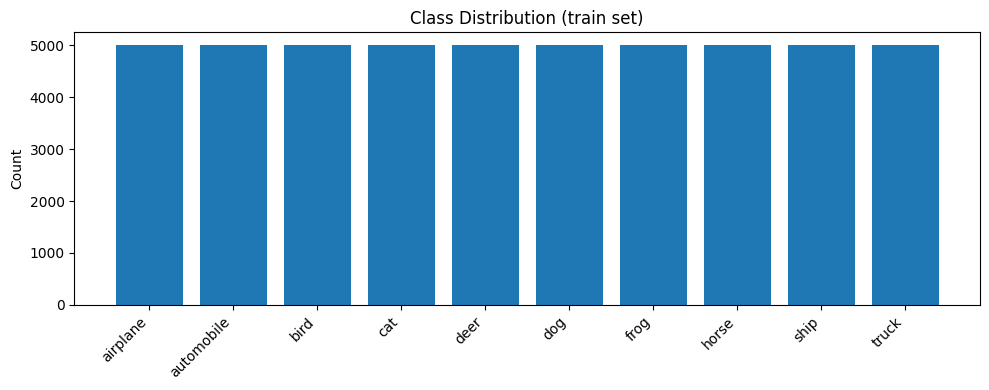

In [4]:
labels = np.array(train_set.targets)
counts = collections.Counter(labels.tolist())

plt.figure(figsize=(10, 4))
plt.bar([class_names[i] for i in range(10)], [counts[i] for i in range(10)])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count")
plt.title("Class Distribution (train set)")
plt.tight_layout()
plt.show()

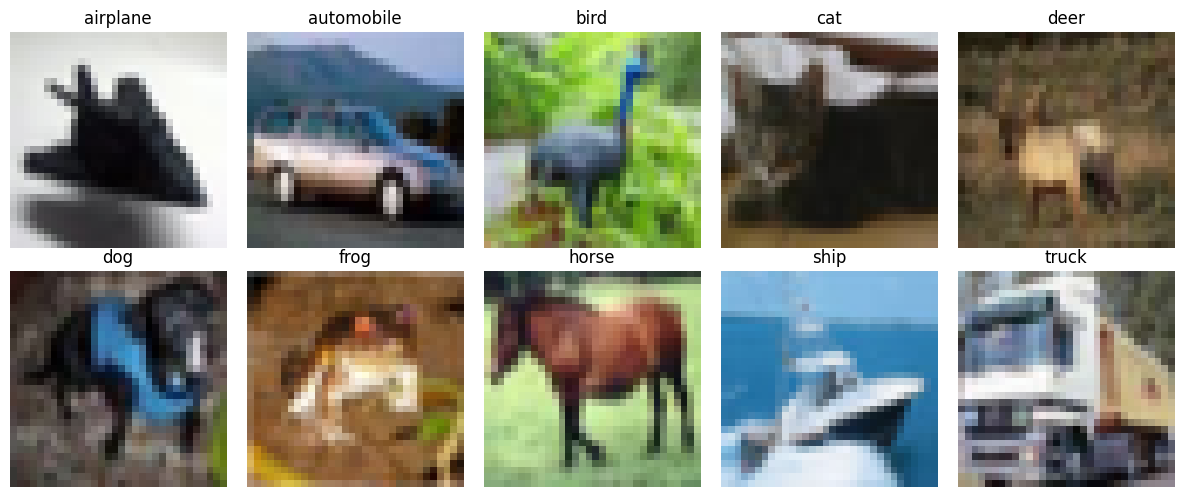

In [5]:
plt.figure(figsize=(12, 5))
for i in range(10):
    idx = int(np.where(labels == i)[0][0])
    img = train_set.data[idx]
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(class_names[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

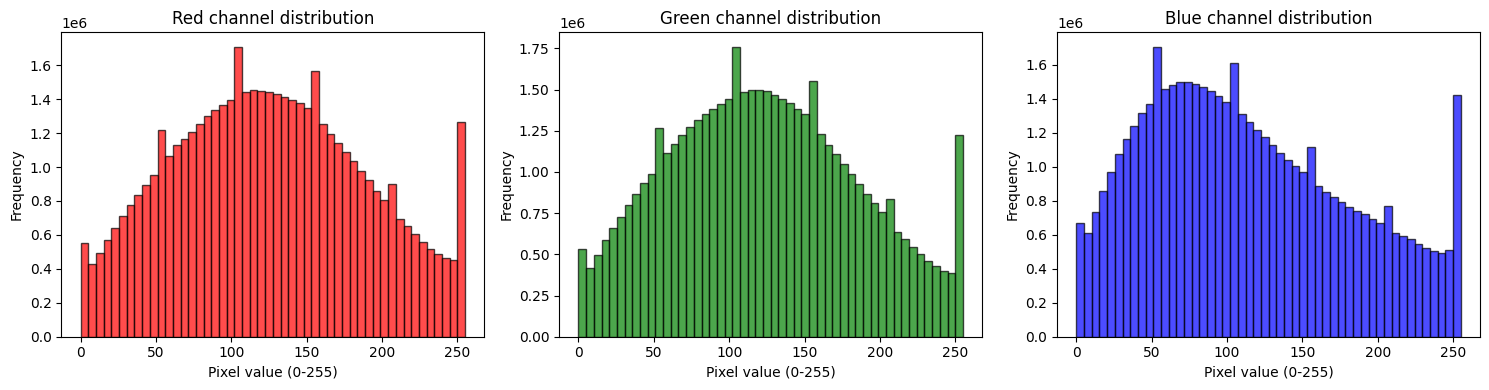

In [6]:
data_np = train_set.data
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['red', 'green', 'blue']
channels = ['Red', 'Green', 'Blue']
for i, (color, ch) in enumerate(zip(colors, channels)):
    axes[i].hist(data_np[:, :, :, i].flatten(), bins=50, color=color, alpha=0.7, edgecolor='black')
    axes[i].set_xlabel("Pixel value (0-255)")
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"{ch} channel distribution")
plt.tight_layout()
plt.show()

## 4. Model 1: MLP

In [7]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3 * 32 * 32, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

## 5. Model 2: CNN

In [8]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32 -> 16
        x = self.pool(F.relu(self.conv2(x)))   # 16 -> 8
        x = self.pool(F.relu(self.conv3(x)))   # 8 -> 4
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## 6. Training and Evaluation Functions

In [9]:
def train_model(model, train_loader, test_loader, epochs=10, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, lbls in train_loader:
            images, lbls = images.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, lbls in test_loader:
                images, lbls = images.to(device), lbls.to(device)
                outputs = model(images)
                preds = outputs.argmax(dim=1)
                correct += (preds == lbls).sum().item()
                total += lbls.size(0)
        acc = correct / total
        test_accuracies.append(acc)

        print(f"  Epoch {epoch+1}/{epochs} - loss: {avg_loss:.4f} - test acc: {acc:.4f}")

    return model, train_losses, test_accuracies


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(lbls.numpy())
    return np.array(all_labels), np.array(all_preds)

## 7. Training the Models

In [10]:
print("MLP:")
mlp, mlp_losses, mlp_accs = train_model(MLP(), train_loader, test_loader, epochs=10)
y_true_mlp, y_pred_mlp = evaluate(mlp, test_loader)

print("\nCNN:")
cnn, cnn_losses, cnn_accs = train_model(CNN(), train_loader, test_loader, epochs=10)
y_true_cnn, y_pred_cnn = evaluate(cnn, test_loader)

MLP:
  Epoch 1/10 - loss: 1.6353 - test acc: 0.4778
  Epoch 2/10 - loss: 1.4263 - test acc: 0.4930
  Epoch 3/10 - loss: 1.3187 - test acc: 0.5134
  Epoch 4/10 - loss: 1.2260 - test acc: 0.5212
  Epoch 5/10 - loss: 1.1436 - test acc: 0.5314
  Epoch 6/10 - loss: 1.0696 - test acc: 0.5332
  Epoch 7/10 - loss: 0.9928 - test acc: 0.5321
  Epoch 8/10 - loss: 0.9170 - test acc: 0.5367
  Epoch 9/10 - loss: 0.8512 - test acc: 0.5297
  Epoch 10/10 - loss: 0.7843 - test acc: 0.5380

CNN:
  Epoch 1/10 - loss: 1.4249 - test acc: 0.6024
  Epoch 2/10 - loss: 1.0086 - test acc: 0.6885
  Epoch 3/10 - loss: 0.8219 - test acc: 0.7130
  Epoch 4/10 - loss: 0.7029 - test acc: 0.7219
  Epoch 5/10 - loss: 0.6133 - test acc: 0.7529
  Epoch 6/10 - loss: 0.5321 - test acc: 0.7519
  Epoch 7/10 - loss: 0.4653 - test acc: 0.7628
  Epoch 8/10 - loss: 0.4033 - test acc: 0.7690
  Epoch 9/10 - loss: 0.3556 - test acc: 0.7625
  Epoch 10/10 - loss: 0.3085 - test acc: 0.7624


## 8. Training Process Visualization

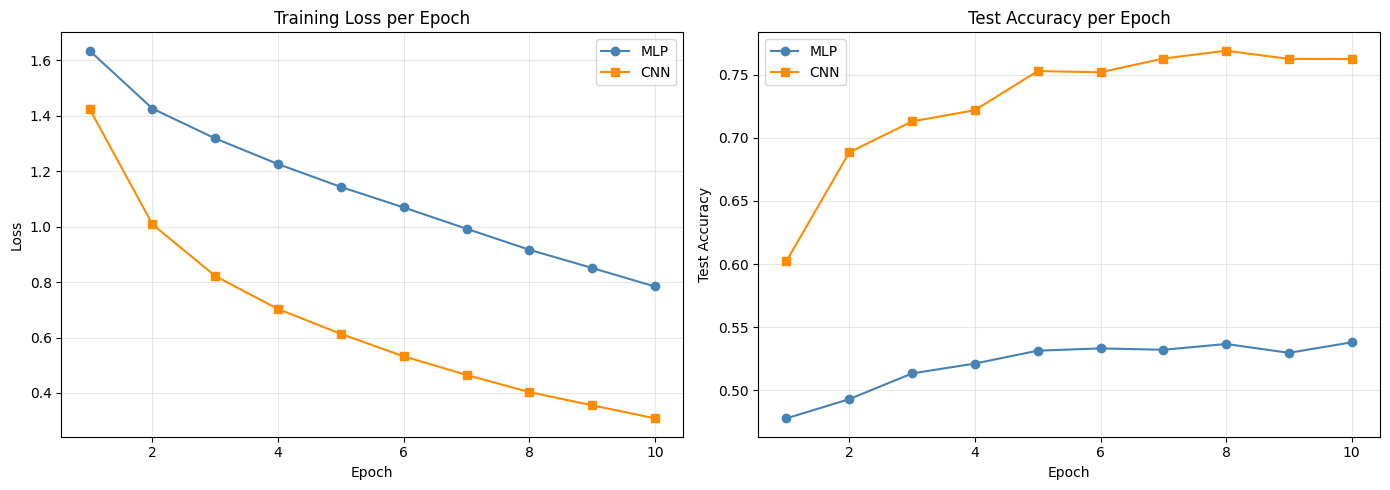

In [11]:
epochs_range = range(1, len(mlp_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, mlp_losses, 'o-', label='MLP', color='steelblue')
axes[0].plot(epochs_range, cnn_losses, 's-', label='CNN', color='darkorange')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss per Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, mlp_accs, 'o-', label='MLP', color='steelblue')
axes[1].plot(epochs_range, cnn_accs, 's-', label='CNN', color='darkorange')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Test Accuracy per Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Model Comparison

In [12]:
acc_mlp = (y_pred_mlp == y_true_mlp).mean()
acc_cnn = (y_pred_cnn == y_true_cnn).mean()
print(f"MLP accuracy: {acc_mlp:.4f}")
print(f"CNN accuracy: {acc_cnn:.4f}")

print("\n=== MLP ===")
print(classification_report(y_true_mlp, y_pred_mlp, target_names=class_names))
print("=== CNN ===")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names))

MLP accuracy: 0.5380
CNN accuracy: 0.7624

=== MLP ===
              precision    recall  f1-score   support

    airplane       0.55      0.62      0.59      1000
  automobile       0.69      0.61      0.65      1000
        bird       0.42      0.45      0.43      1000
         cat       0.35      0.40      0.37      1000
        deer       0.53      0.38      0.44      1000
         dog       0.46      0.41      0.43      1000
        frog       0.57      0.61      0.59      1000
       horse       0.66      0.59      0.62      1000
        ship       0.62      0.71      0.66      1000
       truck       0.56      0.62      0.59      1000

    accuracy                           0.54     10000
   macro avg       0.54      0.54      0.54     10000
weighted avg       0.54      0.54      0.54     10000

=== CNN ===
              precision    recall  f1-score   support

    airplane       0.81      0.78      0.80      1000
  automobile       0.84      0.90      0.87      1000
        bir

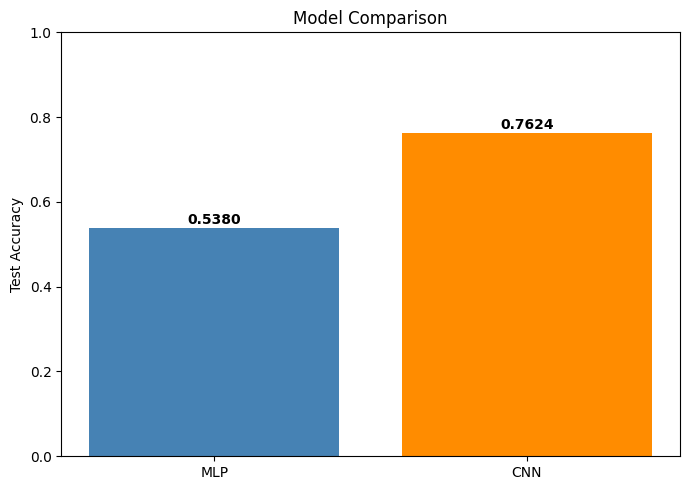

In [13]:
plt.figure(figsize=(7, 5))
models = ['MLP', 'CNN']
accs = [acc_mlp, acc_cnn]
bars = plt.bar(models, accs, color=['steelblue', 'darkorange'])
plt.ylabel("Test Accuracy")
plt.title("Model Comparison")
plt.ylim(0, 1)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{acc:.4f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

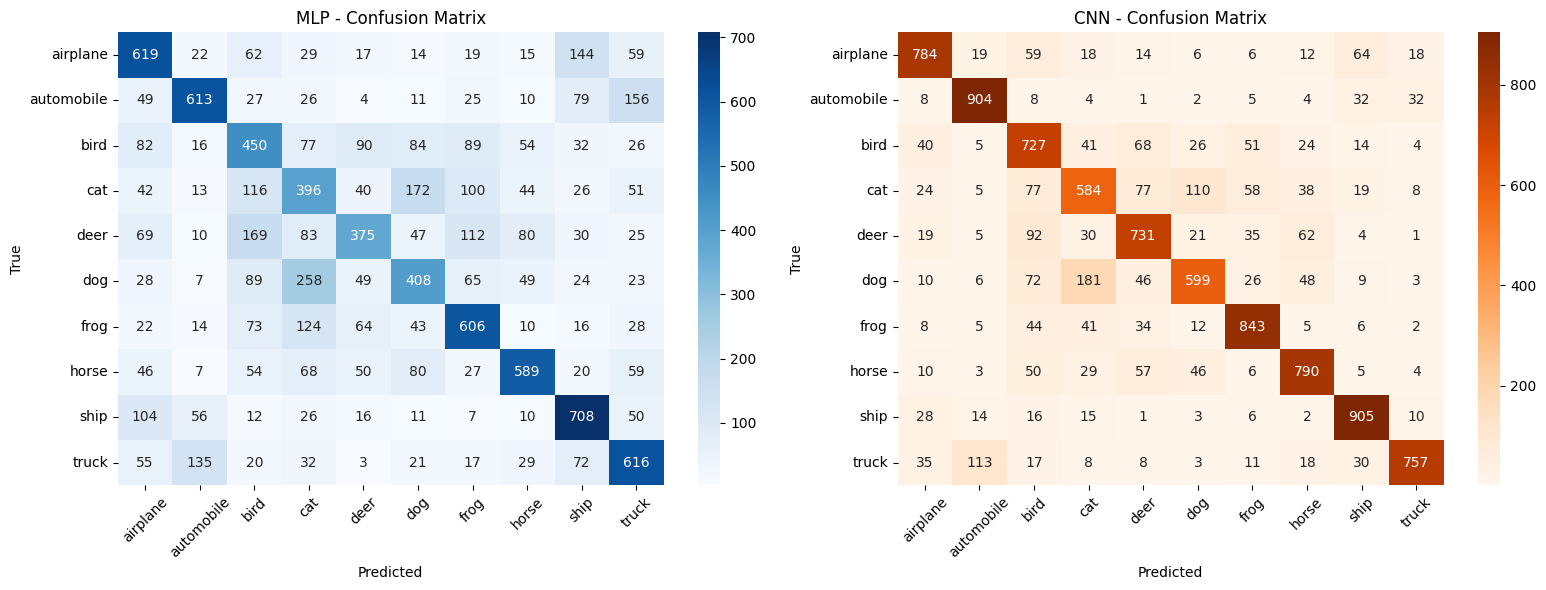

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_mlp = confusion_matrix(y_true_mlp, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("MLP - Confusion Matrix")
axes[0].set_ylabel("True")
axes[0].set_xlabel("Predicted")
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("CNN - Confusion Matrix")
axes[1].set_ylabel("True")
axes[1].set_xlabel("Predicted")
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## 10. CNN Prediction Examples

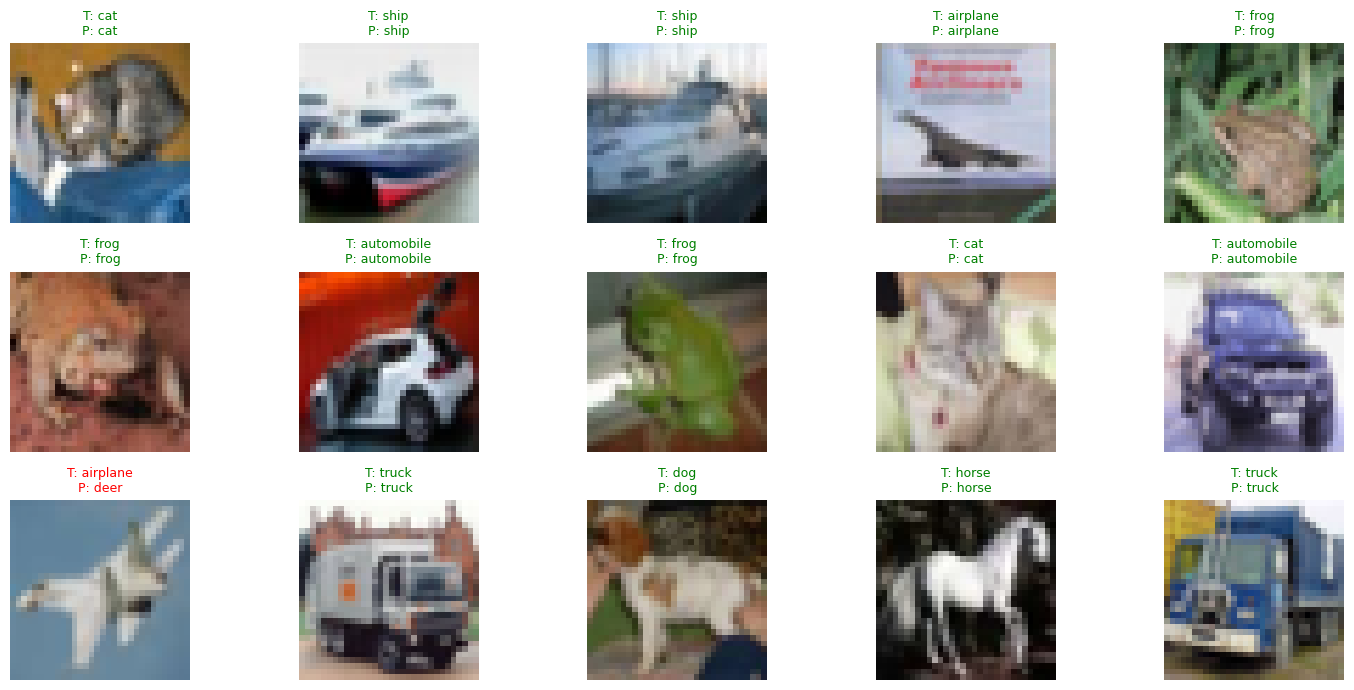

In [15]:
cnn.eval()
images_batch, labels_batch = next(iter(test_loader))
images_batch = images_batch[:15]
labels_batch = labels_batch[:15]

with torch.no_grad():
    outputs = cnn(images_batch.to(device))
    preds = outputs.argmax(dim=1).cpu().numpy()

plt.figure(figsize=(15, 7))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    img = images_batch[i].numpy().transpose(1, 2, 0) * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    true_label = class_names[labels_batch[i].item()]
    pred_label = class_names[preds[i]]
    color = 'green' if preds[i] == labels_batch[i].item() else 'red'
    plt.title(f"T: {true_label}\nP: {pred_label}", color=color, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 11. Қорытынды

CNN MLP-ден айтарлықтай асып түседі, өйткені конволюциондық қабаттар кескіндердің кеңістіктік құрылымын пайдаланады, ал MLP кескінді векторға тегістеу кезінде бұл құрылымды жоғалтады. Қарапайым деректер жиындарына қарағанда CIFAR-10-да алшақтық әлдеқайда үлкен, өйткені нақты әлемдегі түсті кескіндер күрделі кеңістіктік үлгілерді қамтиды.

Ең жиі шатастыратын сыныптар - бұл көзге ұқсас жануарлар (мысық / ит, бұғы / жылқы) және ұқсас көліктер (автокөлік / жүк), өйткені олардың пішіні мен түсі ортақ.

**Мүмкін жақсартулар:** көбірек оқыту эпохалар, деректерді ұлғайту (кездейсоқ кесу, көлденең айналдыру), пакетті қалыпқа келтіру, тереңірек архитектуралар (ResNet, VGG), алдын ала дайындалған үлгілермен оқытуды тасымалдау.